In [1]:
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/Users/shraddha/Documents/DATA_SCIENCE/Shellscope/shellscope")
DATA = ROOT / "data" / "processed"
FIG  = ROOT / "reports" / "figures"
os.makedirs(FIG, exist_ok=True)
print(DATA.exists(), FIG.exists())
df = pd.read_parquet(DATA / "shellscope_companies.parquet",
                     columns=["CompanyNumber", "IncorporationDate", "CompanyStatus",
                              "in_scope", "glasgow", "sic_section"])
print(df.shape)
print(df["CompanyStatus"].value_counts().head(10))
print(df["IncorporationDate"].min(), df["IncorporationDate"].max(),
      df["IncorporationDate"].isna().sum())

True True
(5704711, 6)
CompanyStatus
Active                                              5166057
Active - Proposal to Strike off                      423006
Liquidation                                          108330
In Administration                                      3709
Live but Receiver Manager on at least one charge       2156
Voluntary Arrangement                                   583
In Administration/Administrative Receiver               398
RECEIVERSHIP                                            182
ADMINISTRATION ORDER                                    121
ADMINISTRATIVE RECEIVER                                 104
Name: count, dtype: int64
1327-01-01 00:00:00 2026-10-01 00:00:00 0


In [2]:
inc = df.loc[df["IncorporationDate"] >= "2000-01-01", ["IncorporationDate"]]
monthly = inc.set_index("IncorporationDate").resample("MS").size()

ts = pd.DataFrame({"n": monthly})
ts["roll12"] = ts["n"].rolling(12).mean()
ts["yoy"] = ts["n"].pct_change(12)
print(ts.tail(15).round(3))

                       n     roll12    yoy
IncorporationDate                         
2025-08-01         63439  52291.917  0.632
2025-09-01         71869  54783.583  0.712
2025-10-01         72130  56925.667  0.554
2025-11-01         57089  58330.417  0.419
2025-12-01         49537  59664.500  0.477
2026-01-01         69926  61652.750  0.518
2026-02-01         59472  62798.500  0.301
2026-03-01         73470  64340.500  0.337
2026-04-01         67360  64679.500  0.064
2026-05-01         62487  64737.333  0.011
2026-06-01         63821  64859.833  0.024
2026-07-01         68744  64945.333  0.015
2026-08-01         58697  64550.167 -0.075
2026-09-01         68766  64291.583 -0.043
2026-10-01             1  58280.833 -1.000


In [3]:
daily = inc.set_index("IncorporationDate").resample("D").size()

after      = daily["2025-11-18":"2026-05-17"].mean()
before     = daily["2025-05-18":"2025-11-17"].mean()
year_prior = daily["2024-11-18":"2025-05-17"].mean()

print(f"per day: after {after:.0f} | 6 months before {before:.0f} ({after/before-1:+.1%}) | "
      f"same months a year earlier {year_prior:.0f} ({after/year_prior-1:+.1%})")

per day: after 2054 | 6 months before 2214 (-7.2%) | same months a year earlier 1624 (+26.5%)


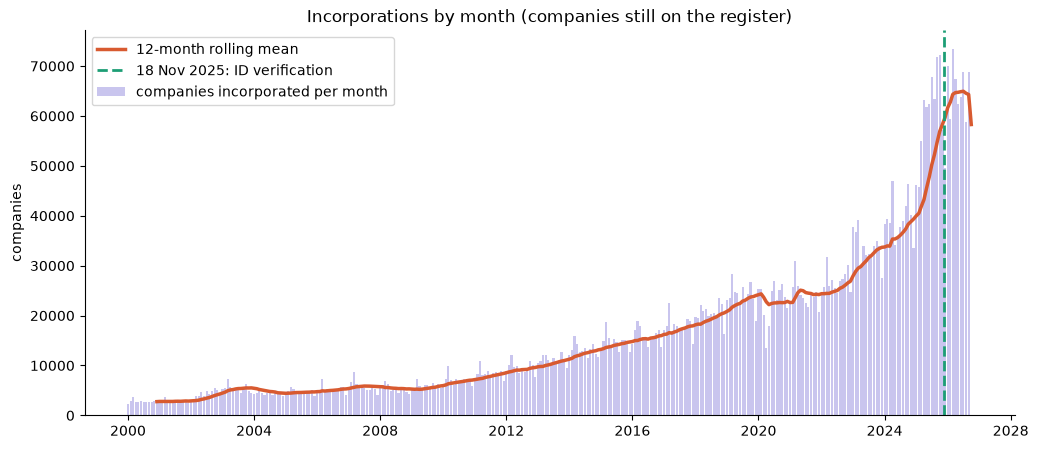

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(ts.index, ts["n"], width=25, color="#C9C5EE", label="companies incorporated per month")
ax.plot(ts.index, ts["roll12"], color="#D85A30", lw=2.5, label="12-month rolling mean")
ax.axvline(pd.Timestamp("2025-11-18"), color="#1D9E75", ls="--", lw=2,
           label="18 Nov 2025: ID verification")
ax.set_title("Incorporations by month (companies still on the register)")
ax.set_ylabel("companies")
ax.legend(loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.savefig(FIG / "01_monthly_incorporations.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
ts = ts.loc[:"2026-09-01"]
print(ts.tail(3).round(3))

                       n     roll12    yoy
IncorporationDate                         
2026-07-01         68744  64945.333  0.015
2026-08-01         58697  64550.167 -0.075
2026-09-01         68766  64291.583 -0.043


In [6]:
daily = inc.set_index("IncorporationDate").resample("D").size()

after      = daily["2025-11-18":"2026-05-17"].mean()
before     = daily["2025-05-18":"2025-11-17"].mean()
year_prior = daily["2024-11-18":"2025-05-17"].mean()

print(f"per day: after {after:.0f} | 6 months before {before:.0f} ({after/before-1:+.1%}) | "
      f"same months a year earlier {year_prior:.0f} ({after/year_prior-1:+.1%})")

per day: after 2054 | 6 months before 2214 (-7.2%) | same months a year earlier 1624 (+26.5%)


In [7]:
cols = ["sic_section", "glasgow", "in_scope", "is_active",
        "accounts_overdue", "strike_off_proposal"]
r = pd.read_parquet(DATA / "shellscope_companies.parquet", columns=cols)

r["od_active"]   = r["accounts_overdue"].astype(float).where(r["in_scope"] & r["is_active"])
r["so_in_scope"] = r["strike_off_proposal"].astype(float).where(r["in_scope"])
r["region"] = np.where(r["glasgow"].fillna(False).astype(bool), "Glasgow (G)", "Rest of UK")

print(r.pivot_table(index="region", values=["od_active", "so_in_scope"], aggfunc="mean").round(4))
print(r["region"].value_counts())


             od_active  so_in_scope
region                             
Glasgow (G)     0.0204       0.0953
Rest of UK      0.0188       0.0762
region
Rest of UK     5621030
Glasgow (G)      83681
Name: count, dtype: int64


In [8]:
cols = ["sic_section", "glasgow", "in_scope", "is_active",
        "accounts_overdue", "strike_off_proposal"]
r = pd.read_parquet(DATA / "shellscope_companies.parquet", columns=cols)

r["od_active"]   = r["accounts_overdue"].astype(float).where(r["in_scope"] & r["is_active"])
r["so_in_scope"] = r["strike_off_proposal"].astype(float).where(r["in_scope"])
r["region"] = np.where(r["glasgow"].fillna(False).astype(bool), "Glasgow (G)", "Rest of UK")

print(r.pivot_table(index="region", values=["od_active", "so_in_scope"], aggfunc="mean").round(4))
print(r["region"].value_counts())

             od_active  so_in_scope
region                             
Glasgow (G)     0.0204       0.0953
Rest of UK      0.0188       0.0762
region
Rest of UK     5621030
Glasgow (G)      83681
Name: count, dtype: int64


In [9]:
reg = r.pivot_table(index="sic_section", columns="region", values="so_in_scope",
                    aggfunc="mean", observed=True)
reg["ratio"] = reg["Glasgow (G)"] / reg["Rest of UK"]
reg["n_glasgow"] = r[r["region"] == "Glasgow (G)"].groupby("sic_section", observed=True).size()
print(reg[reg["n_glasgow"] >= 500].sort_values("ratio", ascending=False).round(3))

region         Glasgow (G)  Rest of UK  ratio  n_glasgow
sic_section                                             
None supplied        0.070       0.031  2.235       5780
Dormant              0.104       0.072  1.434       1120
C                    0.106       0.076  1.382       3382
I                    0.171       0.134  1.274       6982
F                    0.117       0.093  1.264       8240
S                    0.122       0.098  1.240       4161
G                    0.126       0.105  1.195      11421
M                    0.068       0.059  1.158       9149
N                    0.104       0.091  1.148       5480
P                    0.064       0.059  1.089       1373
J                    0.076       0.071  1.082       5561
K                    0.040       0.037  1.081       2716
R                    0.067       0.062  1.080       2212
L                    0.037       0.034  1.077       9694
H                    0.137       0.139  0.990       1844
Q                    0.045     

In [11]:
by_sic = (r.pivot_table(index="sic_section", values=["od_active", "so_in_scope"],
                        aggfunc="mean", observed=True)
            .join(r.groupby("sic_section", observed=True).size().rename("n"))
            .sort_values("so_in_scope", ascending=False))
print(by_sic.round(4))

               od_active  so_in_scope       n
sic_section                                  
H                 0.0181       0.1385  156102
I                 0.0210       0.1347  299004
G                 0.0170       0.1054  743696
U                 0.0403       0.1037     617
O                 0.0155       0.1033   10048
S                 0.0168       0.0988  234864
F                 0.0159       0.0933  571866
E                 0.0201       0.0929   18313
N                 0.0216       0.0909  394042
B                 0.0492       0.0869    8356
C                 0.0210       0.0768  235344
Dormant           0.0198       0.0726  104507
J                 0.0175       0.0707  475327
Q                 0.0145       0.0661  230740
R                 0.0167       0.0625  131211
M                 0.0167       0.0592  676018
P                 0.0150       0.0589  112525
D                 0.0580       0.0533   17845
A                 0.0121       0.0433   44054
K                 0.0330       0.0

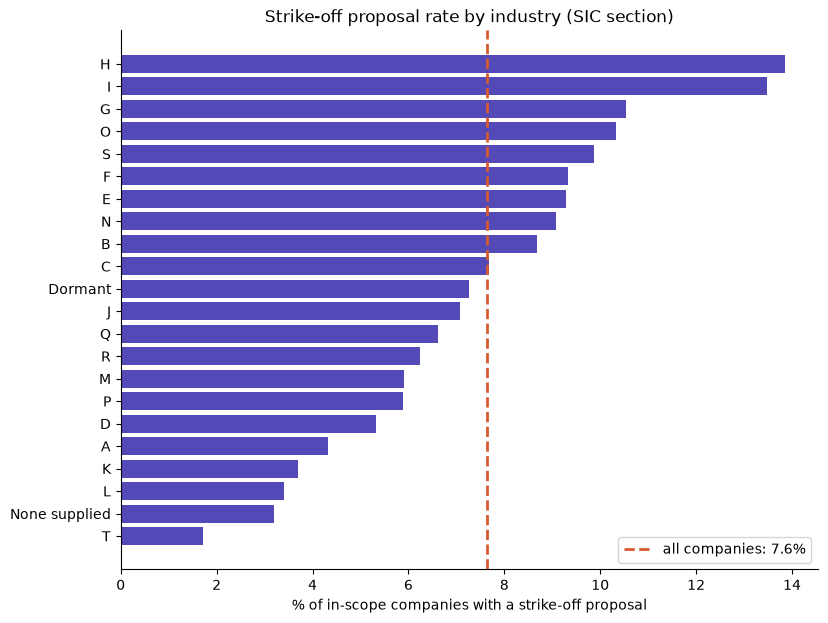

In [12]:
plot = by_sic[by_sic["n"] >= 1000].sort_values("so_in_scope")
base = r["so_in_scope"].mean()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot.index.astype(str), plot["so_in_scope"] * 100, color="#534AB7")
ax.axvline(base * 100, color="#D85A30", ls="--", lw=2, label=f"all companies: {base:.1%}")
ax.set_xlabel("% of in-scope companies with a strike-off proposal")
ax.set_title("Strike-off proposal rate by industry (SIC section)")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.savefig(FIG / "02_strikeoff_by_sic.png", dpi=150, bbox_inches="tight")
plt.show()